In [1]:
using LinearAlgebra
using Random
using Plots
using Printf

n = 100
k = 0.01
ratio_interval = (0.01, 2.0)
points = 50

function make_matrix(n, ratio)
    A = rand(1.0:100.0, n, n)
    for i in 1:n
        S = sum(abs, A[i, :]) - abs(A[i, i])
        A[i, i] = round(ratio * S, digits=2)
    end
    return A
end

function has_diagonal_dominance(A)
    return all(
        abs(A[i, i]) >= sum(abs, A[i, :]) - abs(A[i, i])
        for i in 1:size(A, 1)
    )
end

function gauss(A0, b0)
    A = copy(A0)
    b = copy(b0)
    n = length(b)
    for step in 1:n-1
        for i in step+1:n
            m = A[i, step] / A[step, step]

            for j in step:n
                A[i, j] -= m * A[step, j]
            end

            b[i] -= m * b[step]
        end
    end
    x = zeros(n)
    for i in n:-1:1
        s = 0.0
        for j in i+1:n
            s += A[i, j] * x[j]
        end
        x[i] = (b[i] - s) / A[i, i]
    end
    return x
end

function relative_error(x, x_t)
    return 100 * norm(x_t - x) / norm(x)
end

function vector_string(x, digits)
    format = Printf.Format("%.$(digits)f")
    count = min(5, length(x))
    values = join(
        (Printf.format(format, x[i]) for i in 1:count),
        ", "
    )
    if length(x) > count
        return "[" * values * "] …"
    else
        return "[" * values * "]"
    end
end

vector_string (generic function with 1 method)

In [2]:
A = make_matrix(n, k)

x_t = ones(n)
b = A * x_t

@printf("n = %d\n", n)
@printf("k = %.2f\n", k)

println(
    "Диагональное преобладание: ",
    has_diagonal_dominance(A) ? "есть" : "нет"
)

println()
println("Точное решение")
println("x_t = ", vector_string(x_t, 2))

println()
println("b = ", vector_string(b, 15))

x_r = gauss(A, b)
error_r = relative_error(x_r, x_t)

println()
println("Метод Гаусса")
println("x_r = ", vector_string(x_r, 15))

@printf(
    "Относительная ошибка метода Гаусса = %.10e %%\n",
    error_r
)

x_b = A \ b
error_b = relative_error(x_b, x_t)

println()
println("Библиотека LAPACK")
println("x_b = ", vector_string(x_b, 15))

@printf(
    "Относительная ошибка библиотеки LAPACK = %.10e %%\n",
    error_b
)

n = 100
k = 0.01
Диагональное преобладание: нет

Точное решение
x_t = [1.00, 1.00, 1.00, 1.00, 1.00] …

b = [5205.539999999999964, 5072.220000000000255, 4896.479999999999563, 5118.680000000000291, 5356.029999999999745] …

Метод Гаусса
x_r = [1.000000000004676, 1.000000000000681, 0.999999999998975, 1.000000000001986, 1.000000000002084] …
Относительная ошибка метода Гаусса = 4.9684099822e-10 %

Библиотека LAPACK
x_b = [1.000000000000117, 1.000000000000166, 0.999999999999980, 1.000000000000057, 1.000000000000113] …
Относительная ошибка библиотеки LAPACK = 1.9633607736e-11 %


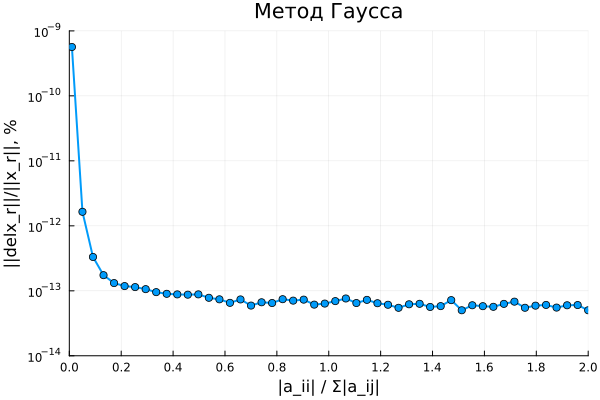

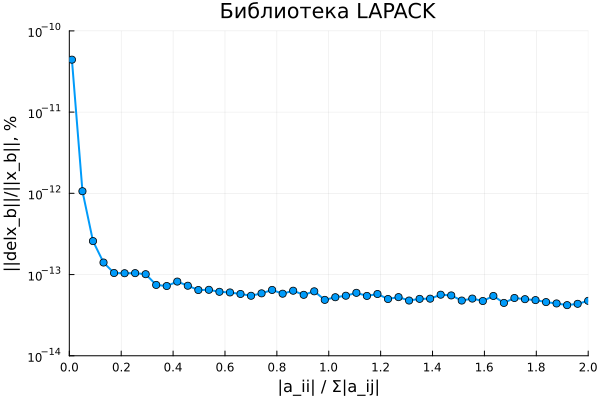

In [3]:
function y_axis(errors)
    min_power = floor(Int, log10(minimum(errors)))
    max_power = ceil(Int, log10(maximum(errors)))
    ticks = 10.0 .^ (min_power:max_power)
    return ticks, (first(ticks), last(ticks))
end

ratios = range(
    ratio_interval[1],
    ratio_interval[2],
    length=points
)

gauss_errors = Float64[]
lapack_errors = Float64[]

for ratio in ratios
    A_current = make_matrix(n, ratio)
    b_current = A_current * x_t

    x_r_current = gauss(A_current, b_current)
    x_b_current = A_current \ b_current

    gauss_error = relative_error(x_r_current, x_t)
    lapack_error = relative_error(x_b_current, x_t)

    gauss_error = max(gauss_error, eps(Float64))
    lapack_error = max(lapack_error, eps(Float64))

    push!(gauss_errors, gauss_error)
    push!(lapack_errors, lapack_error)
end

yticks_r, ylims_r = y_axis(gauss_errors)
yticks_b, ylims_b = y_axis(lapack_errors)

p1 = plot(
    ratios,
    gauss_errors,
    xlabel="|a_ii| / Σ|a_ij|",
    ylabel="||delx_r||/||x_r||, %",
    title="Метод Гаусса",
    xlims=(0, 2),
    xticks=0:0.2:2,
    ylims=ylims_r,
    yticks=yticks_r,
    yscale=:log10,
    linewidth=2,
    marker=:circle,
    legend=false
)

display(p1)

p2 = plot(
    ratios,
    lapack_errors,
    xlabel="|a_ii| / Σ|a_ij|",
    ylabel="||delx_b||/||x_b||, %",
    title="Библиотека LAPACK",
    xlims=(0, 2),
    xticks=0:0.2:2,
    ylims=ylims_b,
    yticks=yticks_b,
    yscale=:log10,
    linewidth=2,
    marker=:circle,
    legend=false
)

display(p2)